In [17]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import fitsio
import glob

import numpy as np
import healpy as hp
import astropy.io.fits as pyfits
import xlens
import astropy.table as astTable
from matplotlib.ticker import MaxNLocator
test_dir = f"/gpfs02/work/xiangchong.li/work/hsc_data/s23b/deepCoadd_anacal_v2/tests_multiband_weight/imag25.0_emax0.40/"
nboot = 10000

g-r $\langle g_1 \rangle$: chi2=5.24, df=5, p=0.3876
g-r $\langle g_2 \rangle$: chi2=10.73, df=5, p=0.0569
r-i $\langle g_1 \rangle$: chi2=5.83, df=5, p=0.3233
r-i $\langle g_2 \rangle$: chi2=5.46, df=5, p=0.3626
i-z $\langle g_1 \rangle$: chi2=2.86, df=5, p=0.7213
i-z $\langle g_2 \rangle$: chi2=10.05, df=5, p=0.0738
[[ 3.23958994e+06  6.55170911e+04 -1.62073423e+06 -8.22914109e+05
  -1.41511918e+05]
 [ 6.55170911e+04  1.62133103e+07 -9.47585243e+06 -5.09747108e+06
  -9.73983648e+05]
 [-1.62073423e+06 -9.47585243e+06  1.24546856e+08 -4.22355353e+07
  -6.27218512e+06]
 [-8.22914109e+05 -5.09747108e+06 -4.22355353e+07  9.01133627e+07
  -6.72967572e+06]
 [-1.41511918e+05 -9.73983648e+05 -6.27218512e+06 -6.72967572e+06
   1.27557268e+07]]
z-y $\langle g_1 \rangle$: chi2=8.69, df=5, p=0.1219
[[ 3.73250052e+06 -6.75708006e+05 -1.91437964e+06 -1.61862271e+06
   1.36369596e+05]
 [-6.75708006e+05  1.66495654e+07 -3.57803025e+06 -6.74691688e+06
  -1.09284645e+06]
 [-1.91437964e+06 -3.57803025e+

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_4159/4251903473.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


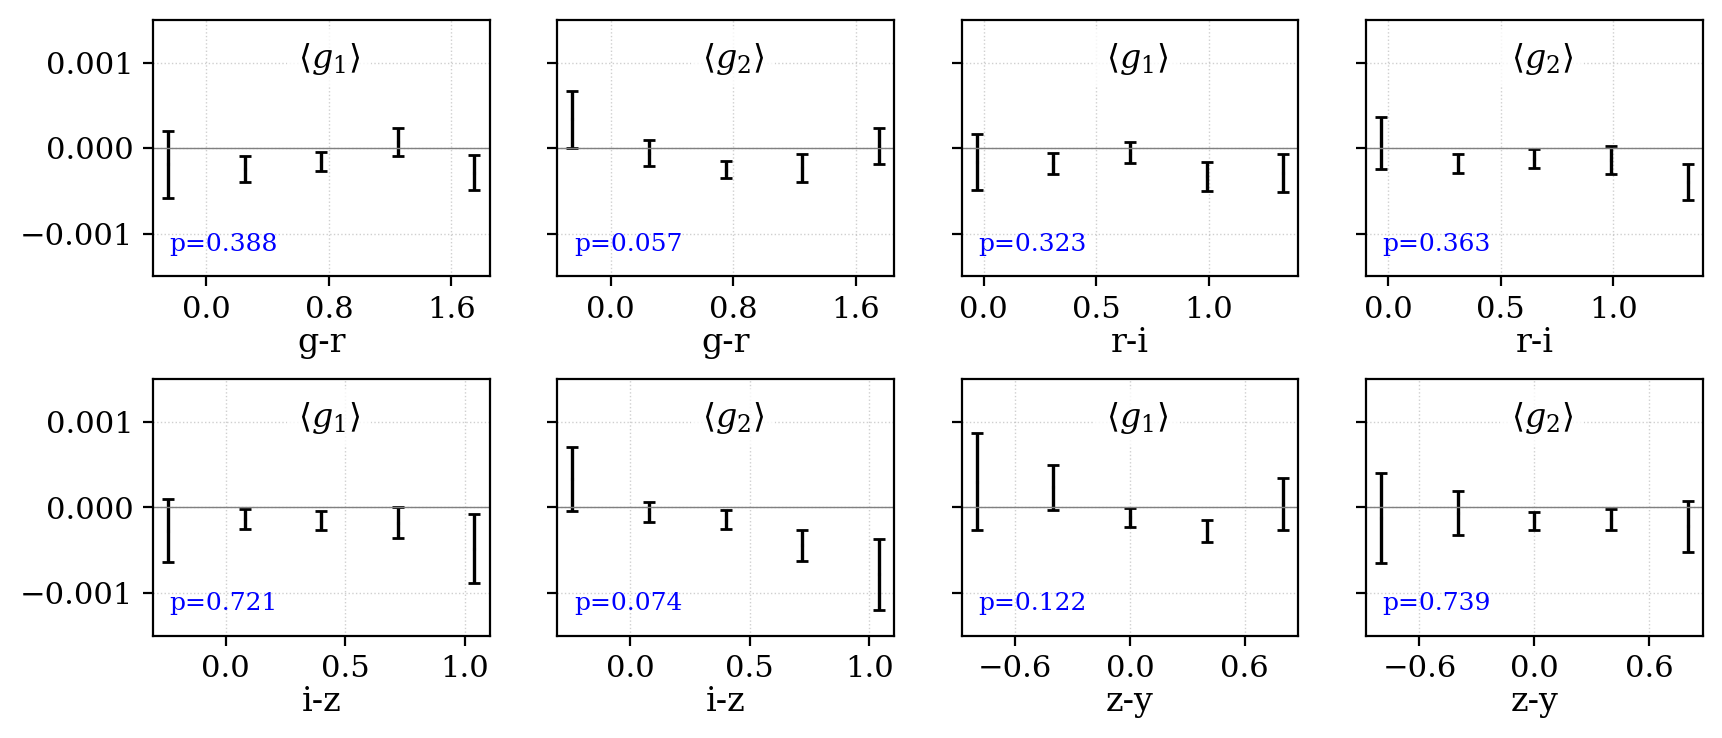

In [18]:
def pvalue_chi2(y, yerr):
    from scipy import stats
    chi2 = np.sum((y / yerr) ** 2)
    df = len(y)
    p = stats.chi2.sf(chi2, df)
    return p, chi2, df

def pvalue_chi2_cov(y, cov, nreal):
    """chi2 = y^T C^{-1} y with Hartlap correction for null test (model = 0).
    
    Hartlap factor: (N - p - 2) / (N - 1), where N = nreal, p = len(y).
    This corrects the bias in the inverse covariance estimated from N samples.
    """
    from scipy import stats
    p_dim = len(y)
    hartlap = (nreal - p_dim - 2) / (nreal - 1)
    cov_inv = np.linalg.inv(cov) * hartlap
    chi2 = y @ cov_inv @ y
    df = p_dim
    p = stats.chi2.sf(chi2, df)
    return p, chi2, df

# Create x, y, yerr, cov for all 8 plots
x_data = []
y_data = []
y_errs = []
y_covs = []
nreal_list = []

def compute_xy(data_subset):
    arr = np.average(data_subset, axis=0)
    x  = arr[0]
    y1 = arr[1] / arr[2]
    y2 = arr[3] / arr[4]
    return x, y1, y2

for ff in ["gr", "ri", "iz", "zy"]:
    data = fitsio.read(f"{test_dir}/{ff}_stack.fits")
    x, y1, y2 = compute_xy(data)

    nreal = data.shape[0]
    y1_boot = np.empty((nboot, y1.size))
    y2_boot = np.empty((nboot, y2.size))

    for i in range(nboot):
        idx = np.random.choice(nreal, size=nreal, replace=True)
        _, y1_i, y2_i = compute_xy(data[idx])
        y1_boot[i] = y1_i
        y2_boot[i] = y2_i

    y1_err = np.std(y1_boot, axis=0) 
    y2_err = np.std(y2_boot, axis=0)
    y1_cov = np.cov(y1_boot, rowvar=False)
    y2_cov = np.cov(y2_boot, rowvar=False)

    x_data.extend([x, x])
    nreal_list.extend([nreal, nreal])
    y_data.extend([y1, y2])
    y_errs.extend([y1_err, y2_err])
    y_covs.extend([y1_cov, y2_cov])

titles = [r'$\langle g_1 \rangle$', r'$\langle g_2 \rangle$'] * 4
xlabels = ["g-r", "g-r", "r-i","r-i", "i-z","i-z", "z-y", "z-y"]

fig, axes = plt.subplots(2, 4, figsize=(10, 4), sharey=True, gridspec_kw={'hspace': 0.4})
axes = axes.flatten()

for i, ax in enumerate(axes):
    x = x_data[i]
    y = y_data[i]
    yerr = y_errs[i]
    cov = y_covs[i]
    nreal = nreal_list[i]
    p, chi2, df = pvalue_chi2_cov(y, cov, nreal)
    ax.errorbar(x, y, yerr=yerr, fmt='s', color='black', markersize=0.1, capsize=2, linewidth=1.2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(True, linestyle=':', linewidth=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.text(0.43, 0.92, titles[i], transform=ax.transAxes,
            fontsize=12, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    ax.text(0.05, 0.08, f"p={p:.3f}", transform=ax.transAxes,
            fontsize=9, va='bottom', ha='left', color='blue')
    ax.set_xlabel(xlabels[i], fontsize=12, labelpad=1)
    ax.set_ylim(-0.0015, 0.0015)
    ax.tick_params(labelsize=11)
    print(f"{xlabels[i]} {titles[i]}: chi2={chi2:.2f}, df={df}, p={p:.4f}")

plt.tight_layout()
plt.show()


PSF $e_1^{(2)}$ $\langle g_1 \rangle$: chi2=5.02, df=5, p=0.4140
PSF $e_2^{(2)}$ $\langle g_2 \rangle$: chi2=16.02, df=5, p=0.0068
PSF $e_1^{(4)}$ $\langle g_1 \rangle$: chi2=15.41, df=5, p=0.0088
PSF $e_2^{(4)}$ $\langle g_2 \rangle$: chi2=5.15, df=5, p=0.3974
PSF FWHM $\langle g_1 \rangle$: chi2=5.93, df=5, p=0.3134
PSF FWHM $\langle g_2 \rangle$: chi2=2.75, df=5, p=0.7387
Noise Variance $\langle g_1 \rangle$: chi2=10.80, df=5, p=0.0556
Noise Variance $\langle g_2 \rangle$: chi2=7.01, df=5, p=0.2197


/gpfs02/work/xiangchong.li/work/tmp/ipykernel_4159/4231107064.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


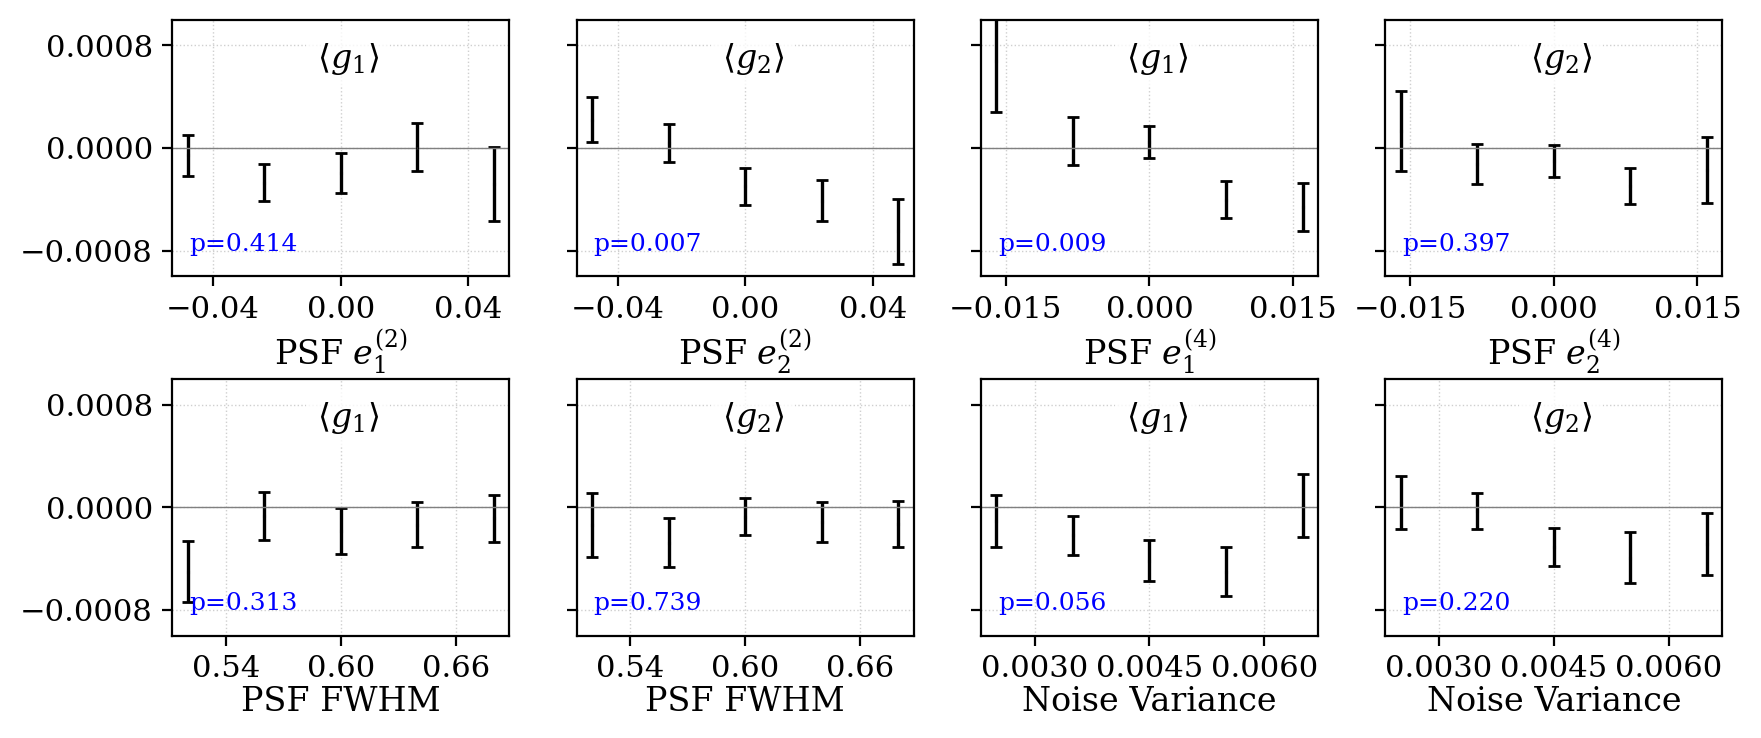

In [19]:
# Create x, y, yerr, cov for all 8 plots (PSF/size/var)
x_data = []
y_data = []
y_errs = []
y_covs = []
nreal_list = []

def compute_xy(data_subset):
    arr = np.average(data_subset, axis=0)
    x  = arr[0]
    y1 = arr[1] / arr[2]
    y2 = arr[3] / arr[4]
    return x, y1, y2

for ff in ["psf2", "psf4", "size", "var"]:
    data = fitsio.read(f"{test_dir}/{ff}_stack.fits")
    x, y1, y2 = compute_xy(data)

    nreal = data.shape[0]
    y1_boot = np.empty((nboot, y1.size))
    y2_boot = np.empty((nboot, y2.size))

    for i in range(nboot):
        idx = np.random.choice(nreal, size=nreal, replace=True)
        _, y1_i, y2_i = compute_xy(data[idx])
        y1_boot[i] = y1_i
        y2_boot[i] = y2_i

    y1_err = np.std(y1_boot, axis=0)
    y2_err = np.std(y2_boot, axis=0)
    y1_cov = np.cov(y1_boot, rowvar=False)
    y2_cov = np.cov(y2_boot, rowvar=False)

    x_data.extend([x, x])
    nreal_list.extend([nreal, nreal])
    y_data.extend([y1, y2])
    y_errs.extend([y1_err, y2_err])
    y_covs.extend([y1_cov, y2_cov])

titles = [r'$\langle g_1 \rangle$', r'$\langle g_2 \rangle$'] * 4
xlabels = [
    r'PSF $e_1^{(2)}$', r'PSF $e_2^{(2)}$',
    r'PSF $e_1^{(4)}$', r'PSF $e_2^{(4)}$',
    'PSF FWHM', 'PSF FWHM',
    'Noise Variance', 'Noise Variance'
]

fig, axes = plt.subplots(2, 4, figsize=(10, 4), sharey=True, gridspec_kw={'hspace': 0.4})
axes = axes.flatten()

for i, ax in enumerate(axes):
    x = x_data[i]
    y = y_data[i]
    yerr = y_errs[i]
    cov = y_covs[i]

    p, chi2, df = pvalue_chi2_cov(y, cov, nreal)
    ax.errorbar(x, y, yerr=yerr, fmt='s', color='black', markersize=0.1, capsize=2, linewidth=1.2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(True, linestyle=':', linewidth=0.5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.text(0.43, 0.92, titles[i], transform=ax.transAxes,
            fontsize=12, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    ax.text(0.05, 0.08, f"p={p:.3f}", transform=ax.transAxes,
            fontsize=9, va='bottom', ha='left', color='blue')
    ax.set_xlabel(xlabels[i], fontsize=12, labelpad=1)
    ax.set_ylim(-0.001, 0.001)
    ax.tick_params(labelsize=11)
    print(f"{xlabels[i]} {titles[i]}: chi2={chi2:.2f}, df={df}, p={p:.4f}")

plt.tight_layout()